# Station Information

* Station name: BLELHAM BECK_FOOTBRIDGE_E_202303
* Water Quality Data link: https://environment.data.gov.uk/hydrology/station/E02614A

## 0. Import the Relevant Libraries

In [1]:
from pathlib import Path
from urllib import request
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

## 1. Import Base Classes and Helper Functions from the Project GitHub and Set Random Seeds

In [2]:
# Import the Base Classes and Helper Functions from the Project GitHub
url = "https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/base_classes_and_helper_functions.py"

file_path = Path("base_classes_and_helper_functions.py")
if not file_path.exists():
    request.urlretrieve(url, file_path)
import base_classes_and_helper_functions as bchf

In [3]:
# Set the random seed for all PNRGs to ensure reproducibility
bchf.set_random_seed()

## 2. Load the Data from the Project GitHub into a Pandas DataFrame

In [6]:
# Create the path to the directory containing the data in the Jupyter notebook environment
data_path = bchf.load_raw_data(url="https://github.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/raw/main/data/processed_data/windermere_inflows_and_outflow/blelham_beck/BLELHAM%20BECK_FOOTBRIDGE_E_202303/BLELHAM%20BECK_FOOTBRIDGE_E_202303_preprocessed_data.zip")

# Assign the full filepath for the preprocessed data
parameter_path = "/content" / data_path / "BLELHAM BECK_FOOTBRIDGE_E_202303_preprocessed_data.csv"

[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [7]:
# Load the data into a Pandas DataFrame
df_parameters = pd.read_csv(parameter_path)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,dateTime,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
0,2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,False,False,False,False,False,False,False,False
1,2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,False,False,False,False,False,False,False,False
2,2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,False,False,False,False,False,False,False,False
3,2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,False,False,False,False,False,False,False,False
4,2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
# Investigate the unique value distributions of the DataFrame
bchf.unique_value_counts(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DISTINCT VALUE COUNTS FOR WATER QUALITY PARAMETER DATAFRAME:
Variable         Number of Distinct Value Counts
dateTime                   45139          

ammonium                    970           

conductivity               10723          

oxygen_conc                1384           

oxygen_perc                8250           

temperature                15869          

turbidity                  3205           

ammonium_impossible             2            

conductivity_impossible             2            

oxygen_conc_impossible             1            

oxygen_perc_impossible             1            

temperature_impossible             2            

turbidity_impossible             2            

ammonium_anomaly             2            

conductivity_anomaly             2            

oxygen_perc_anomaly             2            

turbidity_anomaly             2            

oxygen_conc_anomaly             1            

temperature_anomaly             1            



In [9]:
# Investigate the datatypes and numbers of missing values for each variable
bchf.datatypes_and_missing_values(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
dateTime          , object        ,            0            
ammonium          , float64       ,            0            
conductivity      , float64       ,            0            
oxygen_conc       , float64       ,            0            
oxygen_perc       , float64       ,            0            
temperature       , float64       ,            0            
turbidity         , float64       ,            0            
ammonium_impossible, bool          ,            0            
conductivity_impossible, bool          ,            0            
oxygen_conc_impossible, bool          ,            0            
oxygen_perc_impossible, bool          ,            0            
temperature_impossible, bool          ,            0            
turbidity_impossible, bool          ,            0            
ammonium_anomaly  , bool          ,            0            


## 3. Reindex the DataFrame and Engineer Additional Features for Time Series Modelling

In [10]:
# Change the data type for the dateTime column to datetime64
df_parameters["dateTime"] = pd.to_datetime(df_parameters["dateTime"], dayfirst=False)

# Set the datetime column as the index
df_parameters.set_index('dateTime', inplace=True)

# Investigate the first 5 rows of the reindexed DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
dateTime,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,False,False,False,False,False,False,False,False
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Numerically encode date and time as features
df_parameters["day_of_year"] = df_parameters.index.dayofyear
df_parameters["day_of_year_sin"] = np.sin(2*np.pi*(df_parameters["day_of_year"]/365))
df_parameters["day_of_year_cos"] = np.cos(2*np.pi*(df_parameters["day_of_year"]/365))

df_parameters["minute_of_day"] = df_parameters.index.hour*60 + df_parameters.index.minute
df_parameters["minute_of_day_sin"] = np.sin(2*np.pi*(df_parameters["minute_of_day"]/1440))
df_parameters["minute_of_day_cos"] = np.cos(2*np.pi*(df_parameters["minute_of_day"]/1440))

# Remove redundant columns
df_parameters.drop(["day_of_year", "minute_of_day"], axis=1, inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly,day_of_year_sin,day_of_year_cos,minute_of_day_sin,minute_of_day_cos
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.656059,-0.754710
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.659346,-0.751840
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.700909,-0.713250
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.707107,-0.707107
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,False,False,False,False,False,False,0.989932,0.14154,-0.866025,-0.500000


In [12]:
# Create lagged variables for each feature
variables = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]

for i in np.arange(1, 5):
  for variable in variables:
    df_parameters[f"{variable}_lag{i}"] = df_parameters[variable].shift(periods=i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_lag3,oxygen_perc_lag3,temperature_lag3,turbidity_lag3,ammonium_lag4,conductivity_lag4,oxygen_conc_lag4,oxygen_perc_lag4,temperature_lag4,turbidity_lag4
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,11.26,98.03,9.242,1.44,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,11.27,98.08,9.255,1.45,0.08,75.58,11.26,98.03,9.242,1.44


In [13]:
# Create moving averages for each water quality variable
moving_average_windows = np.array([6, 12, 24]) # hours
timestep_windows = moving_average_windows * 4 # number of timesteps

# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_ma{i}"] = df_parameters[variable].rolling(window=i, min_periods=1).mean()

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_ma48,oxygen_perc_ma48,temperature_ma48,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,11.260000,98.030000,9.242000,1.440000,0.080000,75.580000,11.260000,98.030000,9.242000,1.440000
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,11.265000,98.055000,9.248500,1.445000,0.095000,75.140000,11.265000,98.055000,9.248500,1.445000
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,11.276667,98.176667,9.263667,2.353333,0.083333,74.936667,11.276667,98.176667,9.263667,2.353333
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,11.280000,98.240000,9.274750,2.652500,0.077500,74.822500,11.280000,98.240000,9.274750,2.652500
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,11.284000,98.380000,9.316800,2.822000,0.072000,74.634000,11.284000,98.380000,9.316800,2.822000


In [14]:
# Create seasonal lagged features
seasonality = 96 # 24 hours prior in 15 minute sensor data

target_vars = ["ammonium", "oxygen_conc", "temperature"]

for target in target_vars:
  df_parameters[f"{target}_seasonal_lag{seasonality}"] = df_parameters[target].shift(periods=seasonality)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96,ammonium_seasonal_lag96,oxygen_conc_seasonal_lag96,temperature_seasonal_lag96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,1.440000,0.080000,75.580000,11.260000,98.030000,9.242000,1.440000,NaN,NaN,NaN
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,1.445000,0.095000,75.140000,11.265000,98.055000,9.248500,1.445000,NaN,NaN,NaN
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,2.353333,0.083333,74.936667,11.276667,98.176667,9.263667,2.353333,NaN,NaN,NaN
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,2.652500,0.077500,74.822500,11.280000,98.240000,9.274750,2.652500,NaN,NaN,NaN
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,2.822000,0.072000,74.634000,11.284000,98.380000,9.316800,2.822000,NaN,NaN,NaN


In [15]:
# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_imputed_count_{i}"] = (df_parameters[f"{variable}_impossible"] + df_parameters[f"{variable}_anomaly"]).rolling(window=i, min_periods=1).sum()

# Inpect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_imputed_count_48,oxygen_perc_imputed_count_48,temperature_imputed_count_48,turbidity_imputed_count_48,ammonium_imputed_count_96,conductivity_imputed_count_96,oxygen_conc_imputed_count_96,oxygen_perc_imputed_count_96,temperature_imputed_count_96,turbidity_imputed_count_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 14:44:12,0.08,75.58,11.26,98.03,9.242,1.44,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 14:45:36,0.11,74.70,11.27,98.08,9.255,1.45,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 14:58:13,0.06,74.53,11.30,98.42,9.294,4.17,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 15:00:36,0.06,74.48,11.29,98.43,9.308,3.55,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-03-24 16:00:36,0.05,73.88,11.30,98.94,9.485,3.50,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##4. Create Target Variables for Time Series Prediction

In [16]:
# Create the target variables
timesteps = [1, 2, 4, 24, 48, 96]
for target in target_vars:
    for timestep in timesteps:
        df_parameters[f"{target}_target_t_{str(timestep)}"] = df_parameters[target].shift(periods=-timestep)

# Removed NaN rows added after shifting features and targets
df_parameters.dropna(inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_target_t_4,oxygen_conc_target_t_24,oxygen_conc_target_t_48,oxygen_conc_target_t_96,temperature_target_t_1,temperature_target_t_2,temperature_target_t_4,temperature_target_t_24,temperature_target_t_48,temperature_target_t_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2023-03-28 12:00:36,0.04,79.44,11.10,92.51,7.476,2.99,False,False,False,False,...,11.34,11.15,11.09,11.14,7.570,7.702,7.935,8.697,9.170,8.603
2023-03-28 13:00:36,0.04,79.30,11.15,93.14,7.570,3.13,False,False,False,False,...,11.24,11.17,11.14,11.22,7.702,7.807,8.010,8.880,9.365,8.941
2023-03-28 14:00:36,0.04,79.87,11.26,94.40,7.702,3.01,False,False,False,False,...,11.12,11.16,11.18,11.27,7.807,7.935,8.053,9.002,9.557,9.249
2023-03-28 15:00:36,0.04,79.61,11.33,95.25,7.807,2.99,False,False,False,False,...,10.98,11.06,11.17,11.25,7.935,8.010,8.056,9.089,9.706,9.442
2023-03-28 16:00:36,0.04,79.35,11.34,95.59,7.935,3.01,False,False,False,False,...,10.83,10.97,11.11,11.19,8.010,8.053,8.035,9.156,9.807,9.482


##5. Split Dataset Into Training/Validation/Testing Sets and Normalise Features

In [17]:
# Split the DataFrame into training, validation, and testing sets
df_train, df_val, df_test = bchf.train_val_test_split(df_parameters,
                                                      train_size=0.6,
                                                      val_size=0.2,
                                                      test_size=0.2)

In [18]:
# Initialise the scaler using min-max normalisation (avoid temporal leakage by splitting into training, validation, and testing before fitting the scaler)
feature_scaler = MinMaxScaler()

# Create copies of the DataFrames for scaling
df_train_scaled, df_val_scaled, df_test_scaled = df_train.copy(), df_val.copy(), df_test.copy()

# Create a list of target variables
target_vars = ["ammonium", "oxygen_conc", "temperature"]

# Create a list of features for scaling
features_to_scale = df_train.columns

# Drop anomaly and impossible flags from the features to be scaled list using loop
var_sub_names = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]
for var in var_sub_names:
  features_to_scale = features_to_scale.drop(f"{var}_impossible")
  features_to_scale = features_to_scale.drop(f"{var}_anomaly")

# Drop temporal features from the list of features to be scaled
features_to_scale = features_to_scale.drop("day_of_year_sin")
features_to_scale = features_to_scale.drop("day_of_year_cos")
features_to_scale = features_to_scale.drop("minute_of_day_sin")
features_to_scale = features_to_scale.drop("minute_of_day_cos")

# Remove targets from the list of features for scaling
for target in target_vars:
    for timestep in timesteps:
      features_to_scale = features_to_scale.drop(f"{target}_target_t_{timestep}")

print(features_to_scale)

Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_lag1', 'conductivity_lag1', 'oxygen_conc_lag1',
       'oxygen_perc_lag1', 'temperature_lag1', 'turbidity_lag1',
       'ammonium_lag2', 'conductivity_lag2', 'oxygen_conc_lag2',
       'oxygen_perc_lag2', 'temperature_lag2', 'turbidity_lag2',
       'ammonium_lag3', 'conductivity_lag3', 'oxygen_conc_lag3',
       'oxygen_perc_lag3', 'temperature_lag3', 'turbidity_lag3',
       'ammonium_lag4', 'conductivity_lag4', 'oxygen_conc_lag4',
       'oxygen_perc_lag4', 'temperature_lag4', 'turbidity_lag4',
       'ammonium_ma24', 'conductivity_ma24', 'oxygen_conc_ma24',
       'oxygen_perc_ma24', 'temperature_ma24', 'turbidity_ma24',
       'ammonium_ma48', 'conductivity_ma48', 'oxygen_conc_ma48',
       'oxygen_perc_ma48', 'temperature_ma48', 'turbidity_ma48',
       'ammonium_ma96', 'conductivity_ma96', 'oxygen_conc_ma96',
       'oxygen_perc_ma96', 'temperature_ma96', 'turbidity_ma96

In [19]:
# Fit the scaler to the features during training
feature_scaler.fit(df_train_scaled[features_to_scale])

# Transform the features using min-max normalisation
df_train_scaled[features_to_scale] = feature_scaler.transform(df_train_scaled[features_to_scale])
df_val_scaled[features_to_scale] = feature_scaler.transform(df_val_scaled[features_to_scale])
df_test_scaled[features_to_scale] = feature_scaler.transform(df_test_scaled[features_to_scale])

In [20]:
# Change data types to float32 and int8 to reduce memory and speed up training
float_cols = df_train_scaled.select_dtypes(include='float64').columns # identify column names containing 64 bit floating point data
bool_cols = df_train_scaled.select_dtypes(include='bool').columns # identify column names containing Boolean data

# Loop through DataFrames to convert columns to appropriate data types
for df in [df_train_scaled, df_val_scaled, df_test_scaled]:
  df[float_cols] = df[float_cols].astype('float32')
  df[bool_cols] = df[bool_cols].astype('int8')

In [21]:
# Investigate the datatype and number of missing values for each variable after preparing dataset for modelling
bchf.datatypes_and_missing_values(df_train_scaled, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
ammonium          , float32       ,            0            
conductivity      , float32       ,            0            
oxygen_conc       , float32       ,            0            
oxygen_perc       , float32       ,            0            
temperature       , float32       ,            0            
turbidity         , float32       ,            0            
ammonium_impossible, int8          ,            0            
conductivity_impossible, int8          ,            0            
oxygen_conc_impossible, int8          ,            0            
oxygen_perc_impossible, int8          ,            0            
temperature_impossible, int8          ,            0            
turbidity_impossible, int8          ,            0            
ammonium_anomaly  , int8          ,            0            
conductivity_anomaly, int8          ,            0           

##6. Prepare Data for Forecasting Using Time-Lagged Ridge Regression

In [22]:
# Create list of target variables
targets = []
for target in target_vars:
    for timestep in timesteps:
        targets.append(f"{target}_target_t_{timestep}")

# Create list of features
features = df_train_scaled.columns.drop(targets)

print("Targets:", targets)
print("\nFeatures:", features)

Targets: ['ammonium_target_t_1', 'ammonium_target_t_2', 'ammonium_target_t_4', 'ammonium_target_t_24', 'ammonium_target_t_48', 'ammonium_target_t_96', 'oxygen_conc_target_t_1', 'oxygen_conc_target_t_2', 'oxygen_conc_target_t_4', 'oxygen_conc_target_t_24', 'oxygen_conc_target_t_48', 'oxygen_conc_target_t_96', 'temperature_target_t_1', 'temperature_target_t_2', 'temperature_target_t_4', 'temperature_target_t_24', 'temperature_target_t_48', 'temperature_target_t_96']

Features: Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_impossible', 'conductivity_impossible',
       'oxygen_conc_impossible', 'oxygen_perc_impossible',
       'temperature_impossible', 'turbidity_impossible', 'ammonium_anomaly',
       'conductivity_anomaly', 'oxygen_perc_anomaly', 'turbidity_anomaly',
       'oxygen_conc_anomaly', 'temperature_anomaly', 'day_of_year_sin',
       'day_of_year_cos', 'minute_of_day_sin', 'minute_of_day_cos',
       'ammonium_la

In [23]:
# Create array for training features
X_train = df_train_scaled[features].values
# Create training targets dictionary
y_train_dict = {}
# Populate training targets dictionary with training data
for target in targets:
    key = target
    value = df_train_scaled[target].values
    y_train_dict[key] = value

# Create array for validation features
X_val = df_val_scaled[features].values
# Create validation targets dictionary
y_val_dict = {}
# Populate validation targets dictionary with validation data
for target in targets:
    key = target
    value = df_val_scaled[target].values
    y_val_dict[key] = value

# Create array for testing features
X_test = df_test_scaled[features].values
# Create testing targets dictionary
y_test_dict = {}
# Populate testing targets dictionary with testing data
for target in targets:
    key = target
    value = df_test_scaled[target].values
    y_test_dict[key] = value

In [24]:
# Create dictionaries for scaling targets
target_scaler_dict = {} # dictionary for storing scaler objects
y_train_scaled_dict = {} # dictionary for storing scaled training targets
y_val_scaled_dict = {} # dictionary for storing scaled validation targets
y_test_scaled_dict = {} # dictionary for storing scaled testing targets

# Scale the targets
for target in targets:
    # Instantiate the scaler object
    scaler = MinMaxScaler()
    # Obtain the training targets
    y_train = df_train_scaled[target].values.reshape(-1, 1)
    # Fit the scaler to the training data targets
    scaler.fit(y_train)
    # Scale training data targets and store in dictionary
    y_train_scaled_dict[target] = scaler.transform(y_train)
    # Scale the validation data targets and store in dictionary
    y_val_scaled_dict[target] = scaler.transform(df_val_scaled[target].values.reshape(-1, 1))
    # Scale the testing data targets and store in dictionary
    y_test_scaled_dict[target] = scaler.transform(df_test_scaled[target].values.reshape(-1, 1))
    # Store the fitted scaler in the scaler dictionary
    target_scaler_dict[target] = scaler

##7. Optimise L2 Regularisation Hyperparameter Using Random Search

In [25]:
# Determine the search range for the L2 regularisation hyperparameter
alphas = np.logspace(-4, 4, 30) # search a longnormal distribution between `alpha=0.001` and 'alpha=10,000'

# Create the list of targets that will be used for HPO
hpo_targets = ["ammonium_target_t_96", "oxygen_conc_target_t_96", "temperature_target_t_96"] # use longest forecast horizon for HPO as this is the most complex model

# Create empty dictionaries for holding the best alpha configuration and best validation mse
best_alpha_dict = {}
best_val_mse_dict = {}

In [26]:
# Loop through HPO targets and store best configurations and validation errors
for target in hpo_targets:
    best_mse_val = float("inf") # intialise as infinity to ensure replaced by first evaluated trial
    best_alpha = None # intialise as none to ensure replaced by first evaluated trial
    # Loop through alpha hyperparameter configurations
    for alpha in alphas:
        # Create the model using the current hyperparameter config
        model = Ridge(alpha=alpha)
        # Fit the model to the training data
        model.fit(X_train, y_train_scaled_dict[target])
        # Create predictions using validation data
        y_val_pred = model.predict(X_val)
        # Compute the mean squared error on the validation data
        mse_val = mean_squared_error(y_val_scaled_dict[target], y_val_pred)
        # Store the configuration and error in dictionaries if lower validation error than previous trials
        if mse_val < best_mse_val:
            best_mse_val = mse_val
            best_alpha = alpha
    # Store best alpha config and mean squared validation error in dictionaries for each target
    best_alpha_dict[target] = best_alpha
    best_val_mse_dict[target] = best_mse_val

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.36526e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.57679e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.86341e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.17916e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.73247e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

In [27]:
# Print HPO results
print(f"The best alpha value for ammonium predictions was {best_alpha_dict["ammonium_target_t_96"]} with mean squared validation error {best_val_mse_dict["ammonium_target_t_96"]}")
print(f"The best alpha value for dissolved oxygen predictions was {best_alpha_dict["oxygen_conc_target_t_96"]} with mean squared validation error {best_val_mse_dict["oxygen_conc_target_t_96"]}")
print(f"The best alpha value for temperature predictions was {best_alpha_dict["temperature_target_t_96"]} with mean squared validation error {best_val_mse_dict["temperature_target_t_96"]}")

The best alpha value for ammonium predictions was 10000.0 with mean squared validation error 0.00010099649080075324
The best alpha value for dissolved oxygen predictions was 4.893900918477489 with mean squared validation error 0.001787851331755519
The best alpha value for temperature predictions was 221.22162910704503 with mean squared validation error 0.003179313847795129


##8. Fit the Ridge Regression Model to Training Data and Generate Predictions

In [28]:
# Create a dictionary to hold ridge models
ridge_model_dict = {}

# Create a mapping of each water quality variable name to the optimised hyperparameter config
hpo_target_mapping = {"ammonium": best_alpha_dict["ammonium_target_t_96"],
                      "oxygen": best_alpha_dict["oxygen_conc_target_t_96"],
                      "temperature": best_alpha_dict["temperature_target_t_96"]}

# Instantiate the ridge regression model class for each water quality variable and forecast horizon
for target in targets:
    # Obtain the name of the water quality variable by splitting string on underscores
    var_name = target.split("_")[0] # returns "ammonium", "oxygen", or "temperature"
    # Use ridge model with alpha argument mapping to optimised configuration for each variable
    ridge_model = Ridge(alpha=hpo_target_mapping[var_name])
    # Add the ridge model to the dictionary of models
    ridge_model_dict[target] = ridge_model

In [29]:
# Fit the ridge regression models to the data for each water quality variable and forecast horizon
for target in targets:
    ridge_model_dict[target].fit(X_train, y_train_scaled_dict[target])

In [30]:
# Create a dictionary containing scaled training predictions
y_pred_train_scaled_dict = {}
for target in targets:
    y_pred_train_scaled_dict[target] = ridge_model_dict[target].predict(X_train)

# Create a dictionary containing scaled validation predictions
y_pred_val_scaled_dict = {}
for target in targets:
    y_pred_val_scaled_dict[target] = ridge_model_dict[target].predict(X_val)

# Create a dictionary containing scaled test predictions
y_pred_test_scaled_dict = {}
for target in targets:
    y_pred_test_scaled_dict[target] = ridge_model_dict[target].predict(X_test)

In [31]:
# Create a dictionary containing descaled training predictions
y_pred_train_dict = {}
for target in targets:
    y_pred_train_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_train_scaled_dict[target].reshape(-1, 1)).flatten()

# Create a dictionary containing descaled validation predictions
y_pred_val_dict = {}
for target in targets:
    y_pred_val_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_val_scaled_dict[target].reshape(-1, 1)).flatten()

# Create a dictionary containing descaled test predictions
y_pred_test_dict = {}
for target in targets:
    y_pred_test_dict[target] = target_scaler_dict[target].inverse_transform(y_pred_test_scaled_dict[target].reshape(-1, 1)).flatten()

##9. Evaluate Ridge Regression Model Performance

In [32]:
# Evaluate predictions against targets for each water quality variable and forecast horizon on training, validation, and testing sets
for target in targets:
    print(f"\nTRAINING PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_train_dict[target],
                                           y_pred=y_pred_train_dict[target]))
    print(f"VALIDATION PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_val_dict[target],
                                           y_pred=y_pred_val_dict[target]))
    print(f"TEST PERFORMANCE FOR {target.upper()}:")
    print(bchf.compute_performance_metrics(y_obs=y_test_dict[target],
                                           y_pred=y_pred_test_dict[target]))
    print("---------------------------------------------------------------")


TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.1727670282125473, 'RMSE': 0.4156525433063507, 'MAE': 0.12147721648216248, 'r^2': 0.3733544945716858, 'NSE': np.float32(0.3733545)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.006022889167070389, 'RMSE': 0.07760727405548096, 'MAE': 0.06288035959005356, 'r^2': -1.1672990322113037, 'NSE': np.float32(-1.167299)}
TEST PERFORMANCE FOR AMMONIUM_TARGET_T_1:
{'MSE': 0.006577293388545513, 'RMSE': 0.08110051602125168, 'MAE': 0.0696941465139389, 'r^2': -3.1186184883117676, 'NSE': np.float32(-3.1186185)}
---------------------------------------------------------------

TRAINING PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.17342832684516907, 'RMSE': 0.4164472818374634, 'MAE': 0.12167000025510788, 'r^2': 0.37095433473587036, 'NSE': np.float32(0.37095433)}
VALIDATION PERFORMANCE FOR AMMONIUM_TARGET_T_2:
{'MSE': 0.006036027334630489, 'RMSE': 0.07769187539815903, 'MAE': 0.0629354938864708, 'r^2': -1.1721277236938477, 'NSE': np.float

##10. Plot Ridge Regression Model Predictions Against Observations

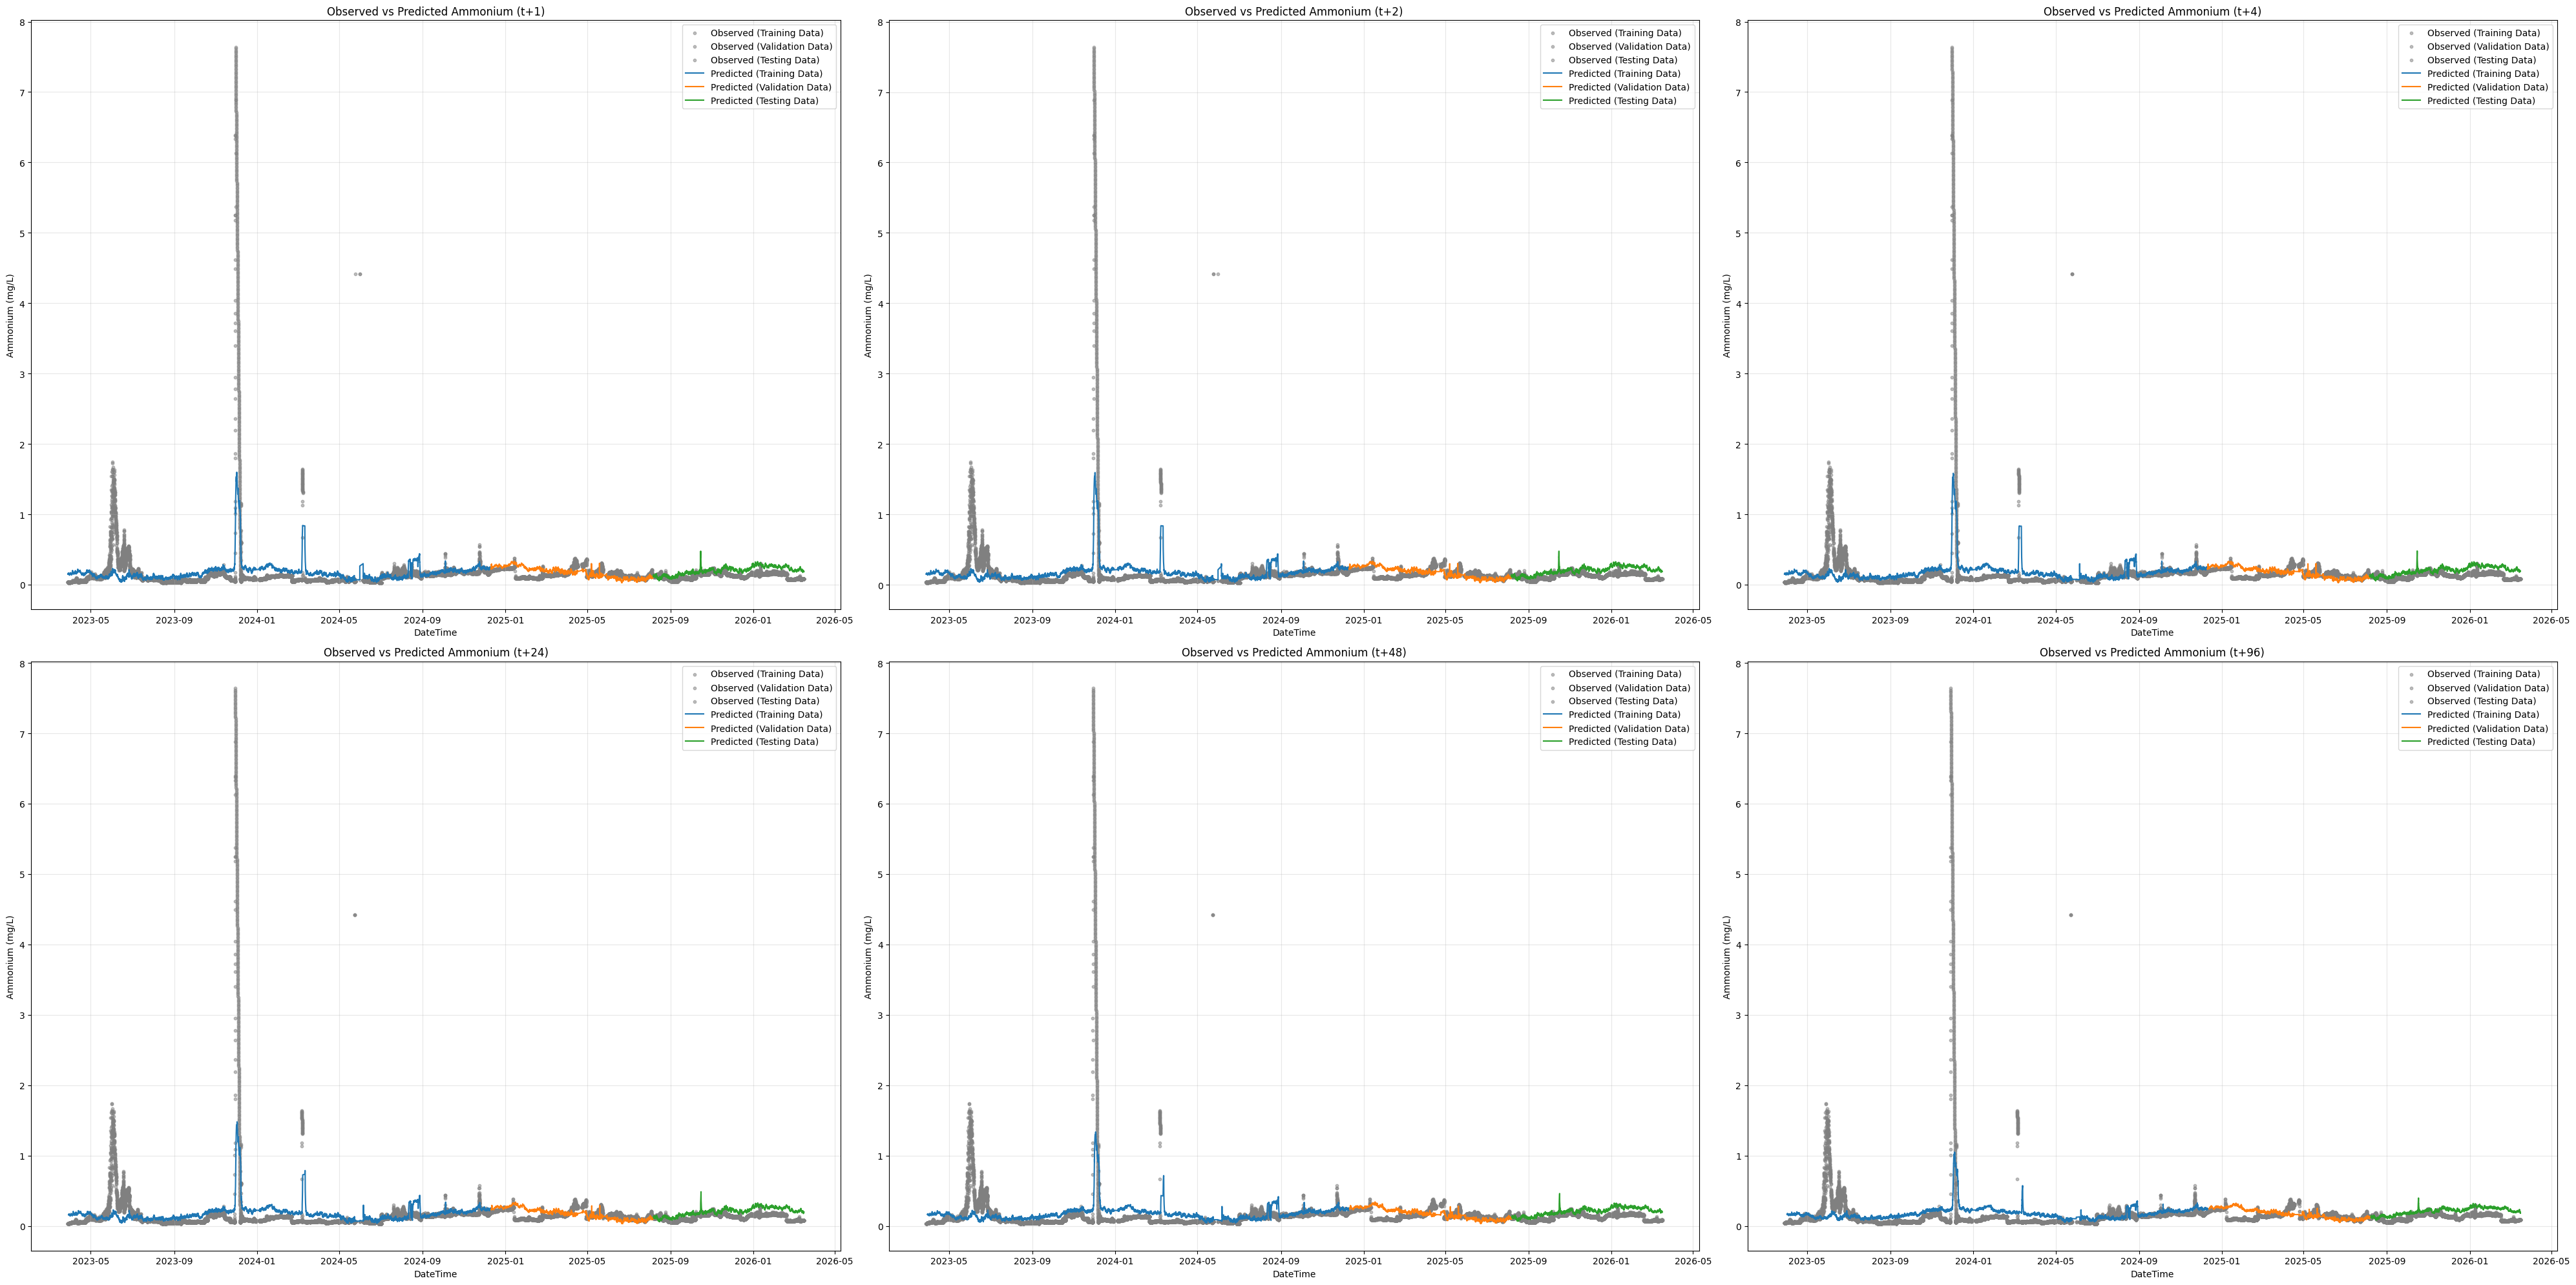

In [33]:
# Create a list of ammonium_targets
NUM_VARIABLES = 3 # 3 target variables: ammonium, dissolved oxygen, and temperature
ammonium_targets = targets[:int(len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(ammonium_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(ammonium_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Ammonium (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Ammonium (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


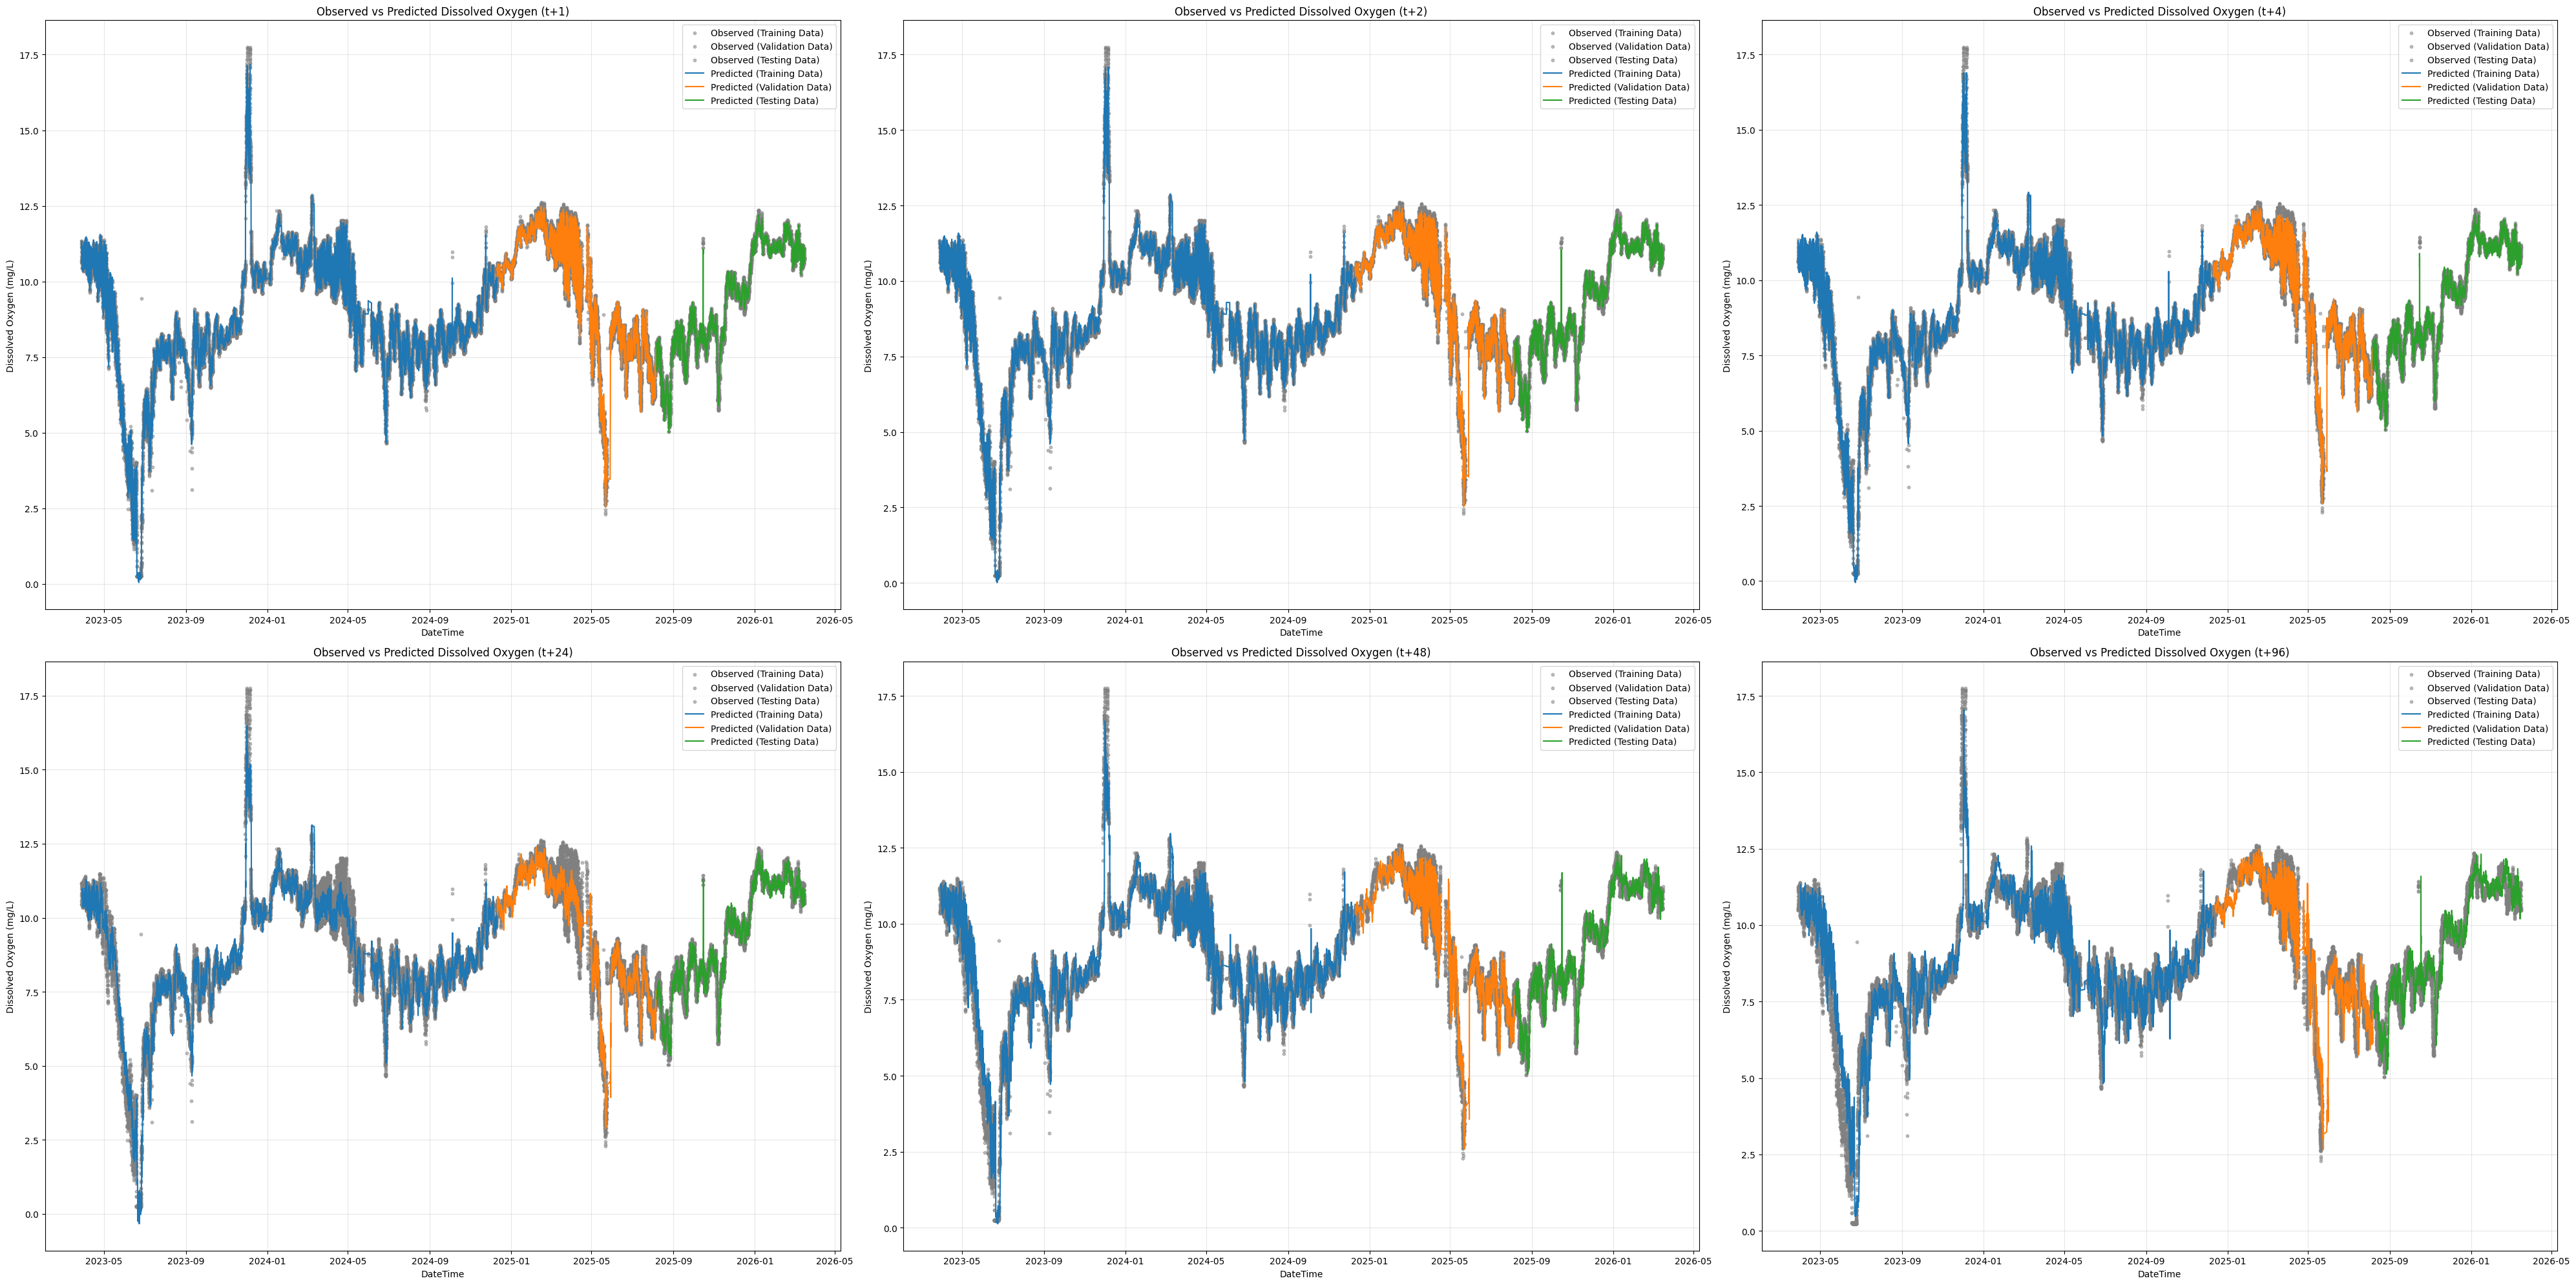

In [34]:
# Create a list of dissolved oxygen targets
oxygen_targets = targets[int(len(targets)/3):int(2*len(targets)/3)]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(oxygen_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through ammonium targets for plotting
for i, target in enumerate(oxygen_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Dissolved Oxygen (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Dissolved Oxygen (mg/L)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

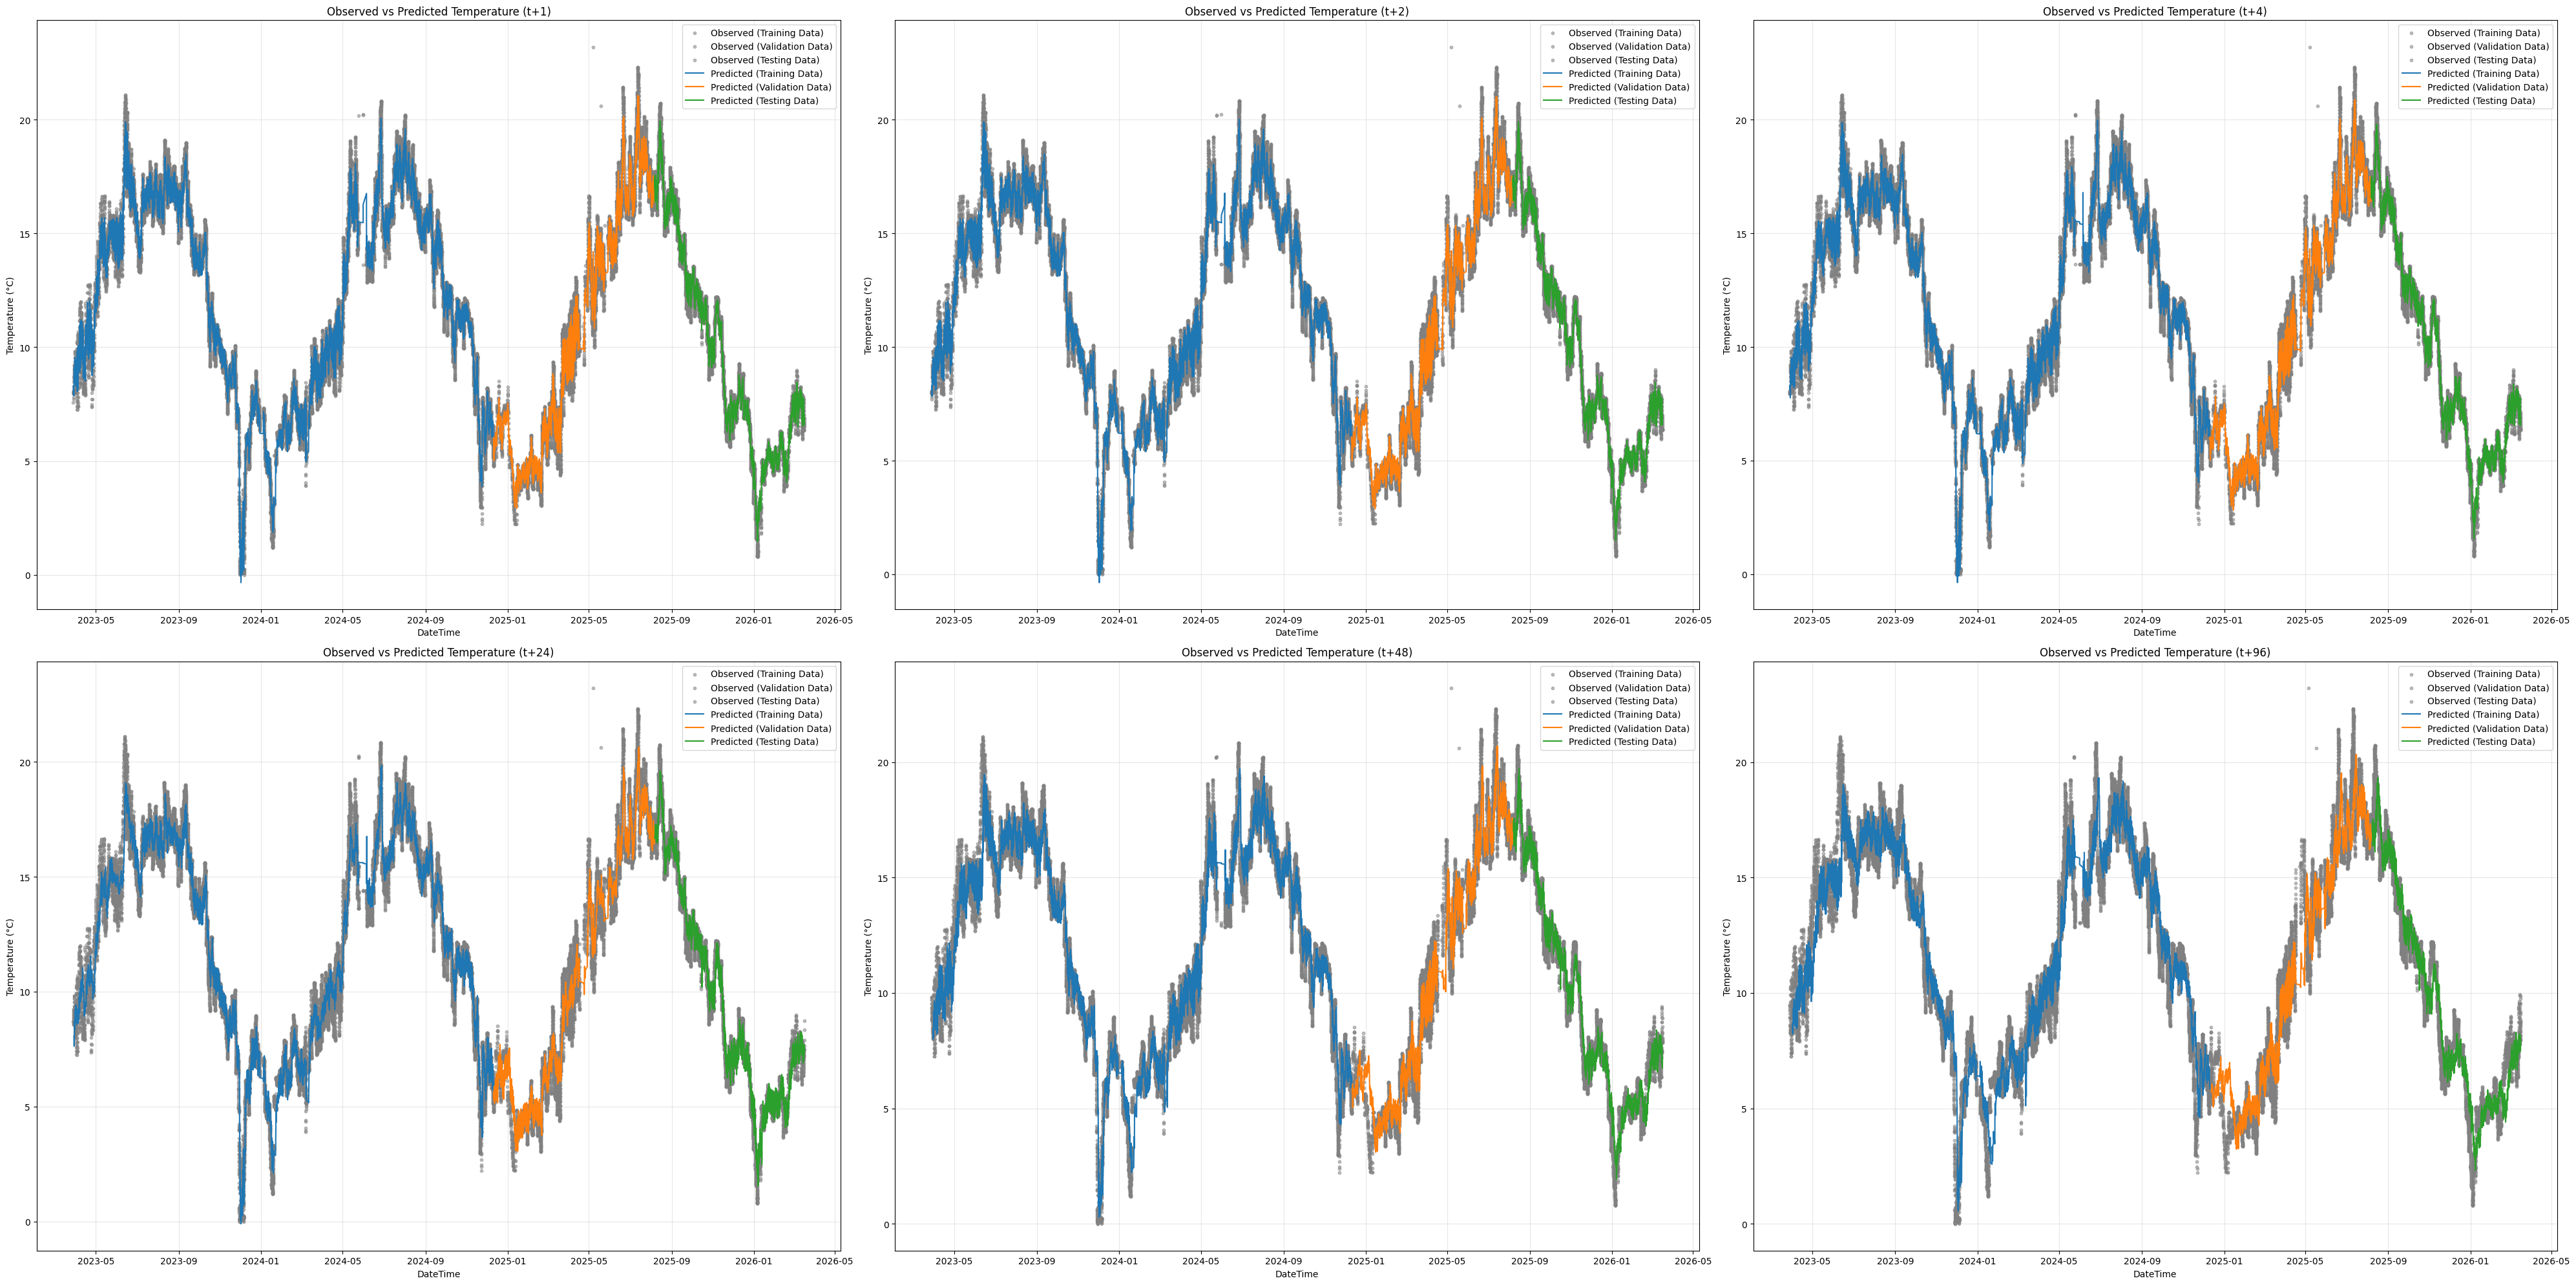

In [35]:
# Create a list of temperature targets
temperature_targets = targets[-int(len(targets)/3):]

# Create a figure and sets of axes to plot ammonium predictions against observations
N_ROWS = 2
fig, axes = plt.subplots(nrows=N_ROWS, ncols=int(len(temperature_targets)/N_ROWS), figsize=(40, 20))
axes = axes.flatten()  # flatten 2D array of axes for indexing

# Loop through temperature targets for plotting
for i, target in enumerate(temperature_targets):
    ax = axes[i]

    # Compute the forecast horizon for offsetting prediction plots to match time index
    horizon = int(target.split('_')[-1])

    # Plot observed data
    ax.scatter(df_train.index, y_train_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Training Data)')
    ax.scatter(df_val.index, y_val_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Validation Data)')
    ax.scatter(df_test.index, y_test_dict[target], color='gray', s=10, alpha=0.5, label='Observed (Testing Data)')

    # Plot predictions
    ax.plot(df_train.index[horizon:], y_pred_train_dict[target][:-horizon], color="tab:blue", label="Predicted (Training Data)")
    ax.plot(df_val.index[horizon:], y_pred_val_dict[target][:-horizon], color="tab:orange", label="Predicted (Validation Data)")
    ax.plot(df_test.index[horizon:], y_pred_test_dict[target][:-horizon], color="tab:green", label="Predicted (Testing Data)")

    # Customize the plot
    horizon = target.split('_')[-1]
    ax.set_title(f"Observed vs Predicted Temperature (t+{horizon})")
    ax.set_xlabel("DateTime")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()